# 07 — Peer- / Stärke-Performance der Top-Spielerinnen

**Drei Fragen pro Alters-Kohorte, jeweils aufgeteilt nach Gegnerstärke und Gegner-Geschlecht:**
1. Wie viele Partien insgesamt — stärker / gleich / schwächer?
2. Wie ist der **Gesamt-Erfolg** (Σ `rating_change_weighted`) — insgesamt und je Bucket?
3. Wie ist der **Ø Erfolg pro Partie** — insgesamt und je Bucket?

**Definitionen:**
- Stärke-Bucket (Schwelle ±80 Elo): `stärker` = Gegner > ich + 80; `gleich` = |Differenz| ≤ 80; `schwächer` = Gegner < ich − 80
- Alters-Kohorten: Alter **in 2015** (Anker wie Notebook 06): <20, 20–30, 30–40, 40–50, >50

**Filter:** `analysis_group='female_top' AND active=TRUE`, Gegner aufgelöst mit `sex ∈ {M,F}`, eigenes Rating vorhanden.

In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()
pd.set_option('display.max_rows', 250)

## Datenbasis laden

In [16]:
sql = '''
SELECT
    gr.fide_id,
    p.birth_year,
    rh.std_rating       AS own_rating,
    gr.opponent_rating,
    opp.sex             AS opponent_sex,
    gr.rating_change_weighted
FROM game_results gr
JOIN players p         ON p.fide_id = gr.fide_id
JOIN rating_history rh ON rh.fide_id = gr.fide_id AND rh.period = gr.period
JOIN players opp       ON opp.fide_id = gr.opponent_fide_id
WHERE p.analysis_group = 'female_top'
  AND p.active = TRUE
  AND opp.sex IN ('M','F')
'''
df = load_query(sql)
df['rating_change_weighted'] = df['rating_change_weighted'].astype(float)
df['diff'] = df['opponent_rating'] - df['own_rating']
df['age_2015'] = 2015 - df['birth_year']

def age_bucket(a):
    if pd.isna(a): return 'unknown'
    if a < 20: return '<20'
    if a < 30: return '20-30'
    if a < 40: return '30-40'
    if a < 50: return '40-50'
    return '>50'
df['cohort'] = df['age_2015'].apply(age_bucket)

def strength_bucket(d):
    if d >  80: return 'stärker'
    if d < -80: return 'schwächer'
    return 'gleich'
df['strength'] = df['diff'].apply(strength_bucket)

COHORT_ORDER   = ['<20','20-30','30-40','40-50','>50']
STRENGTH_ORDER = ['stärker','gleich','schwächer']
SEX_ORDER      = ['F','M']
SEX_PALETTE    = {'F':'#c0587e','M':'#4a7ab5'}
STRENGTH_PAL   = {'stärker':'#2c7bb6','gleich':'#888888','schwächer':'#d7191c'}

# aktive Kohorten (nicht leer)
active_cohorts = [c for c in COHORT_ORDER if c in df['cohort'].unique()]
print(f'Partien: {len(df):,}   Spielerinnen: {df.fide_id.nunique()}   Kohorten: {active_cohorts}')
df.head()

Task was destroyed but it is pending!
task: <Task pending name='Task-145' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/macminipit/Projekte/fide-scraper/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-146' coro=<Kernel.shell_main() running at /Users/macminipit/Projekte/fide-scraper/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/macminipit/Projekte/fide-scraper/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/macminipit/Projekte/fide-scraper/.venv/lib/python3.13/site-packages/pandas/io/sql.py:2796: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = cur.fetchall()
Task was destroyed but it is pending!
task: <Task pending name='Task-146' coro=<Kernel.shell_main() running at /Users/macminipit/Projekte/fide-scraper/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.

Partien: 22,664   Spielerinnen: 43   Kohorten: ['<20', '20-30', '30-40']


,fide_id,birth_year,own_rating,opponent_rating,opponent_sex,rating_change_weighted,diff,age_2015,cohort,strength
0,13604040,1994,2366,2450,F,1.2,84,21,20-30,stärker
1,13604040,1994,2366,2122,F,2.0,-244,21,20-30,schwächer
2,13604040,1994,2366,2315,F,-5.7,-51,21,20-30,gleich
3,13604040,1994,2366,2073,F,1.5,-293,21,20-30,schwächer
4,13604040,1994,2366,2473,F,-3.5,107,21,20-30,stärker


## Helper: Tabellen-Bau

Pro Metrik eine Tabelle mit Zeilen = `(cohort, strength)` + Kohorten-Gesamt-Zeile und
Spalten = `vs F | vs M | gesamt`.

In [17]:
def build_table(df, aggfunc, round_to=0):
    '''aggfunc: 'size' | 'sum' | 'mean' auf rating_change_weighted.'''
    col = 'rating_change_weighted'
    def agg(sub):
        if aggfunc == 'size': return len(sub)
        if aggfunc == 'sum':  return sub[col].sum()
        if aggfunc == 'mean': return sub[col].mean() if len(sub) else np.nan

    rows = []
    for c in active_cohorts:
        sub_c = df[df.cohort == c]
        # per strength
        for s in STRENGTH_ORDER:
            sub_cs = sub_c[sub_c.strength == s]
            rows.append({
                'cohort': c, 'bucket': s,
                'vs F':   agg(sub_cs[sub_cs.opponent_sex == 'F']),
                'vs M':   agg(sub_cs[sub_cs.opponent_sex == 'M']),
                'gesamt': agg(sub_cs),
            })
        # cohort total
        rows.append({
            'cohort': c, 'bucket': 'alle',
            'vs F':   agg(sub_c[sub_c.opponent_sex == 'F']),
            'vs M':   agg(sub_c[sub_c.opponent_sex == 'M']),
            'gesamt': agg(sub_c),
        })
    tbl = pd.DataFrame(rows).set_index(['cohort','bucket'])
    if aggfunc == 'size':
        tbl = tbl.astype(int)
    else:
        tbl = tbl.round(round_to if round_to else 1)
    return tbl

## Frage 1 — Partien insgesamt

Anzahl Partien pro Kohorte × Stärke-Bucket, aufgeteilt nach Gegner-Geschlecht.
`alle` = Summe über alle drei Stärke-Buckets.

In [18]:
t_n = build_table(df, aggfunc='size')
t_n

vs F  vs M  gesamt
cohort bucket                       
<20    stärker     993  2324    3317
       gleich     2438  1105    3543
       schwächer  4206  2222    6428
       alle       7637  5651   13288
20-30  stärker     100   428     528
       gleich     2063   351    2414
       schwächer  2581   522    3103
       alle       4744  1301    6045
30-40  stärker     106   216     322
       gleich     1070   175    1245
       schwächer  1381   383    1764
       alle       2557   774    3331

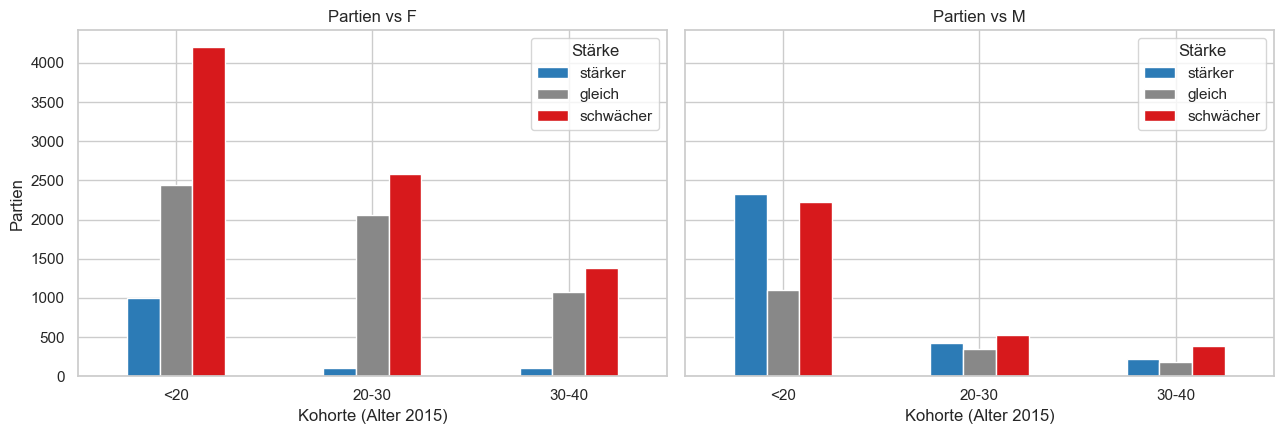

In [19]:
# Plot: Partien pro Kohorte × Stärke, facettiert vs F / vs M
plot_df = t_n.reset_index()
plot_df = plot_df[plot_df.bucket != 'alle']
plot_df['bucket'] = pd.Categorical(plot_df['bucket'], STRENGTH_ORDER, ordered=True)
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], active_cohorts, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sex in zip(axes, SEX_ORDER):
    sub = plot_df.pivot(index='cohort', columns='bucket', values=f'vs {sex}')
    sub = sub.reindex(active_cohorts)[STRENGTH_ORDER]
    sub.plot.bar(ax=ax, color=[STRENGTH_PAL[s] for s in STRENGTH_ORDER],
                 edgecolor='white')
    ax.set_title(f'Partien vs {sex}')
    ax.set_xlabel('Kohorte (Alter 2015)')
    ax.set_ylabel('Partien')
    ax.legend(title='Stärke')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Frage 2 — Gesamt-Erfolg (Σ rating_change_weighted)

Summierte Elo-Punkte pro Kohorte × Stärke-Bucket × Gegner-Geschlecht.

In [20]:
t_sum = build_table(df, aggfunc='sum', round_to=1)
t_sum

vs F    vs M   gesamt
cohort bucket                            
<20    stärker    3676.4  5327.4   9003.9
       gleich     1552.1   939.4   2491.4
       schwächer  -345.2  -675.8  -1021.0
       alle       4883.3  5591.0  10474.3
20-30  stärker      56.5    99.7    156.2
       gleich      268.6    -1.5    267.1
       schwächer  -594.3    11.5   -582.8
       alle       -269.2   109.7   -159.5
30-40  stärker       7.1   -31.7    -24.6
       gleich      111.9   -29.5     82.4
       schwächer  -665.3    72.4   -592.9
       alle       -546.3    11.2   -535.1

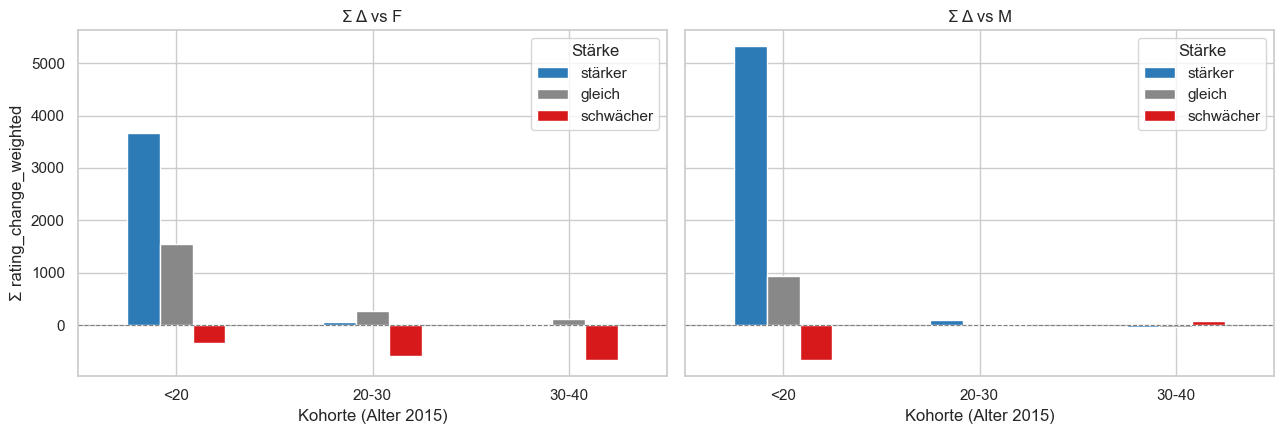

In [21]:
plot_df = t_sum.reset_index()
plot_df = plot_df[plot_df.bucket != 'alle']
plot_df['bucket'] = pd.Categorical(plot_df['bucket'], STRENGTH_ORDER, ordered=True)
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], active_cohorts, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sex in zip(axes, SEX_ORDER):
    sub = plot_df.pivot(index='cohort', columns='bucket', values=f'vs {sex}')
    sub = sub.reindex(active_cohorts)[STRENGTH_ORDER]
    sub.plot.bar(ax=ax, color=[STRENGTH_PAL[s] for s in STRENGTH_ORDER],
                 edgecolor='white')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(f'Σ Δ vs {sex}')
    ax.set_xlabel('Kohorte (Alter 2015)')
    ax.set_ylabel('Σ rating_change_weighted')
    ax.legend(title='Stärke')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Frage 3 — Ø Erfolg pro Partie (Ø rating_change_weighted)

Durchschnittliche Elo-Änderung je Partie — zeigt, wie effizient gespielt wird.

In [22]:
t_mean = build_table(df, aggfunc='mean', round_to=3)
t_mean

vs F   vs M  gesamt
cohort bucket                         
<20    stärker    3.702  2.292   2.714
       gleich     0.637  0.850   0.703
       schwächer -0.082 -0.304  -0.159
       alle       0.639  0.989   0.788
20-30  stärker    0.565  0.233   0.296
       gleich     0.130 -0.004   0.111
       schwächer -0.230  0.022  -0.188
       alle      -0.057  0.084  -0.026
30-40  stärker    0.067 -0.147  -0.076
       gleich     0.105 -0.169   0.066
       schwächer -0.482  0.189  -0.336
       alle      -0.214  0.014  -0.161

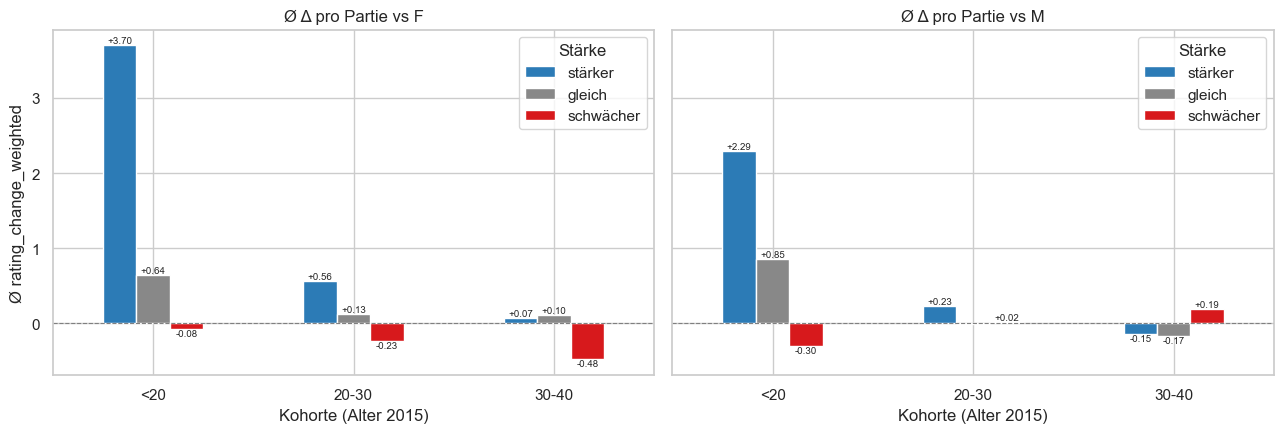

In [23]:
plot_df = t_mean.reset_index()
plot_df = plot_df[plot_df.bucket != 'alle']
plot_df['bucket'] = pd.Categorical(plot_df['bucket'], STRENGTH_ORDER, ordered=True)
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], active_cohorts, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sex in zip(axes, SEX_ORDER):
    sub = plot_df.pivot(index='cohort', columns='bucket', values=f'vs {sex}')
    sub = sub.reindex(active_cohorts)[STRENGTH_ORDER]
    sub.plot.bar(ax=ax, color=[STRENGTH_PAL[s] for s in STRENGTH_ORDER],
                 edgecolor='white')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(f'Ø Δ pro Partie vs {sex}')
    ax.set_xlabel('Kohorte (Alter 2015)')
    ax.set_ylabel('Ø rating_change_weighted')
    ax.legend(title='Stärke')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and abs(h) > 0.01:
            ax.annotate(f'{h:+.2f}', (p.get_x()+p.get_width()/2, h),
                        ha='center', va='bottom' if h>=0 else 'top', fontsize=7)
plt.tight_layout(); plt.show()

### CSV-Export der drei Tabellen

In [ ]:
with pd.ExcelWriter('peer_performance.xlsx') as xw:
    t_n.to_excel(xw,    sheet_name='Partien')
    t_sum.to_excel(xw,  sheet_name='Erfolg_Summe')
    t_mean.to_excel(xw, sheet_name='Erfolg_pro_Partie')
t_n.to_csv('peer_performance_n.csv')
t_sum.to_csv('peer_performance_sum.csv')
t_mean.to_csv('peer_performance_mean.csv')
print('wrote peer_performance.xlsx + 3 CSVs')